In [2]:
import pandas as pd

# 0. Load the cleaned dataset from Notebook 1
df_clean = pd.read_csv("marketing_campaign_cleaned.csv")

# --- STEP 4.1: RFM Metric Setup & Quartile Scoring ---

# 1. Create RFM Dataframe
rfm = df_clean[['ID', 'Recency', 'Total_Purchases', 'Total_Spend']].copy()
rfm.rename(columns={'Total_Purchases': 'Frequency', 'Total_Spend': 'Monetary'}, inplace=True)

# 2. Score metrics from 1 to 4 using quartiles
# Recency: Lower values are better (more recent), so labels are [4, 3, 2, 1]
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])

# Frequency & Monetary: Higher values are better, so labels are [1, 2, 3, 4]
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

# 3. Combine scores into an RFM Segment Code and calculate an overall Score
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

# Preview the calculated RFM metrics
rfm.head()

,ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,5524,58,25,1617,2,4,4,244,10
1,2174,38,6,27,3,1,1,311,5
2,4141,26,21,776,3,3,3,333,9
3,6182,26,8,53,3,1,1,311,5
4,5324,94,19,422,1,3,3,133,7


In [3]:
# Map numerical RFM scores to business segments
def segment_customer(df):
    if df['RFM_Score'] >= 10:
        return 'Champions'
    elif df['RFM_Score'] >= 8:
        return 'Loyal Customers'
    elif df['RFM_Score'] >= 6:
        return 'Promising / Potential'
    elif df['RFM_Score'] >= 4:
        return 'At Risk'
    else:
        return 'Lost / Inactive'

rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)

# Display segment summary counts
print(rfm['Customer_Segment'].value_counts())

Customer_Segment
Loyal Customers          640
Champions                533
Promising / Potential    519
At Risk                  426
Lost / Inactive          118
Name: count, dtype: int64


In [4]:
# Aggregate RFM metrics across segments
segment_summary = rfm.groupby('Customer_Segment')[['Recency', 'Frequency', 'Monetary']].agg(
    Customer_Count=('Recency', 'count'),
    Avg_Recency_Days=('Recency', 'mean'),
    Avg_Purchases=('Frequency', 'mean'),
    Avg_Spend=('Monetary', 'mean')
).reindex(['Champions', 'Loyal Customers', 'Promising / Potential', 'At Risk', 'Lost / Inactive']).round(2)

segment_summary

,Customer_Count,Avg_Recency_Days,Avg_Purchases,Avg_Spend
Customer_Segment,,,,
Champions,533,27.39,22.80,1200.77
Loyal Customers,640,55.04,18.76,866.32
Promising / Potential,519,44.25,10.36,236.34
At Risk,426,63.06,7.27,78.30
Lost / Inactive,118,86.21,5.29,38.29


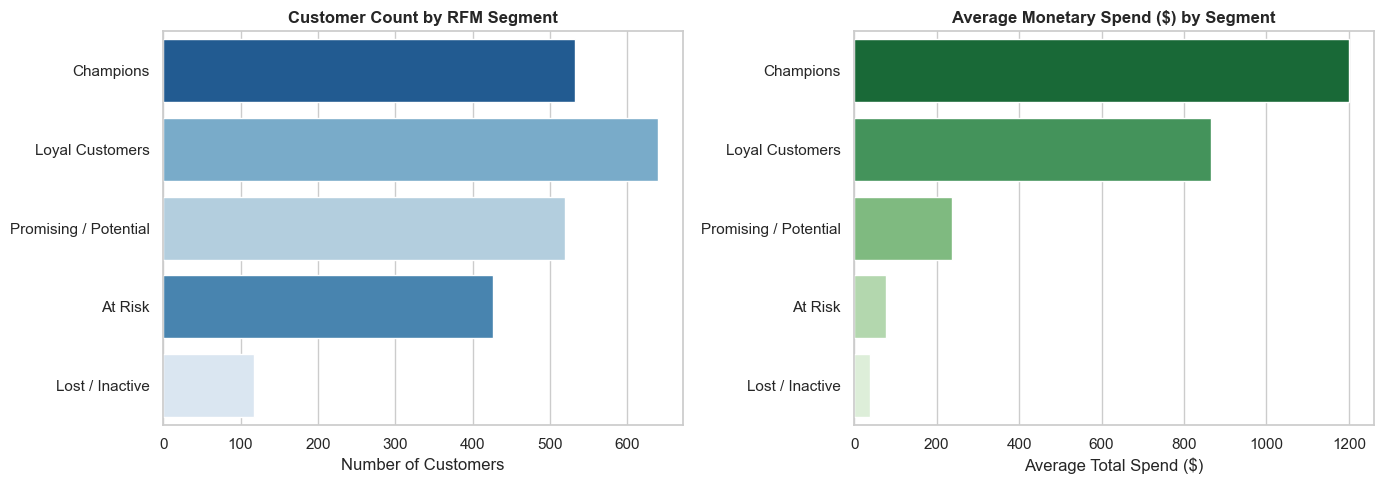

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Plot 1: Segment Distribution
plt.subplot(1, 2, 1)
order = ['Champions', 'Loyal Customers', 'Promising / Potential', 'At Risk', 'Lost / Inactive']
ax1 = sns.countplot(
    data=rfm,
    y='Customer_Segment',
    order=order,
    hue='Customer_Segment',
    palette='Blues_r',
    legend=False,
)
plt.title('Customer Count by RFM Segment', fontsize=12, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('')

# Plot 2: Average Spend by Segment
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    data=segment_summary.reset_index(),
    y='Customer_Segment',
    x='Avg_Spend',
    order=order,
    hue='Customer_Segment',
    palette='Greens_r',
    legend=False,
)
plt.title('Average Monetary Spend ($) by Segment', fontsize=12, fontweight='bold')
plt.xlabel('Average Total Spend ($)')
plt.ylabel('')

plt.tight_layout()
plt.show()
plt.savefig('rfm_segments.png')

In [6]:
# Merge segment classifications back into df_clean
df_segmented = df_clean.merge(rfm[['ID', 'RFM_Segment', 'RFM_Score', 'Customer_Segment']], on='ID', how='inner')

# Save final segmented dataset for modeling or dashboarding (e.g., Power BI / Streamlit)
df_segmented.to_csv("marketing_campaign_segmented.csv", index=False)
print("Segmented dataset exported successfully with shape:", df_segmented.shape)

Segmented dataset exported successfully with shape: (2236, 35)
